# Laboratorio 5 — Regresión logística desde cero

El modelo de clasificación probabilística no tiene solución cerrada: hay que ajustarlo
iterando. Este laboratorio construye las cuatro piezas y las verifica contra
`scikit-learn`:

1. La **función logística**, numéricamente estable.
2. La **entropía cruzada**, contrastada con `log_loss`.
3. Su **gradiente**, verificado contra diferencias finitas.
4. El **ajuste completo**, que reutiliza el descenso por gradiente ya escrito.

Y después lo que justifica todo lo anterior: **interpretar los coeficientes**. Como el
conjunto de datos es sintético y se conoce el modelo que lo generó, cada estimación se
puede contrastar contra su valor verdadero.

Hay **siete ejercicios**. Las celdas que contienen `raise NotImplementedError()` deben
completarse; el resto es andamiaje y se ejecuta sin modificar.

## 0. Preparación

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (8, 3.6), "axes.grid": True, "grid.alpha": 0.3})
np.set_printoptions(precision=4, suppress=True)

AZUL, TURQUESA, NARANJA = "#19326E", "#50ACB0", "#CD742A"
VIOLETA, OLIVA, AZUL_CLARO = "#A3477F", "#89A943", "#4294CC"

### Los datos

4000 solicitudes de crédito de consumo con su desenlace observado. **La clase positiva es
el incumplimiento**: `incumplio = 1` significa que el crédito no se pagó.

In [3]:
#@title Carga del conjunto de datos (ejecutar sin modificar) { display-mode: "form" }

datos = pd.read_csv("https://raw.githubusercontent.com/gustavovazquez/datasets/refs/heads/main/riesgo_credito.csv")
print(f"Cargado: {datos.shape[0]} filas x {datos.shape[1]} columnas")
print(f"Tasa de incumplimiento: {datos['incumplio'].mean():.1%}")
datos.head(3)

Cargado: 4000 filas x 12 columnas
Tasa de incumplimiento: 21.8%


,id_solicitud,edad_anios,antiguedad_laboral_anios,ingreso_mensual_usd,monto_solicitado_usd,plazo_meses,cuota_mensual_usd,cuota_ingreso,historial_crediticio,consultas_buro_12m,tiene_garantia,incumplio
0,SC-02061,36,13.4,1690.0,5960.0,24,344.08,0.2036,al dia,0,0,0
1,SC-00934,36,5.0,900.0,8640.0,36,441.03,0.4900,sin historial,2,0,1
2,SC-00379,52,2.0,540.0,800.0,36,43.12,0.0799,con atrasos,2,0,0


### Las variables

El historial crediticio es categórico con tres niveles. Se lo codifica dejando **«al día»
como categoría de referencia**: los dos coeficientes resultantes se leen siempre respecto
de ella. El monto entra en logaritmo y la edad, centrada, porque así fueron generados.

In [4]:
#@title Construcción de la matriz de diseño (ejecutar sin modificar) { display-mode: "form" }
tabla = datos.copy()
tabla["hist_atrasos"] = (tabla["historial_crediticio"] == "con atrasos").astype(int)
tabla["hist_sin"] = (tabla["historial_crediticio"] == "sin historial").astype(int)
tabla["log_monto"] = np.log(tabla["monto_solicitado_usd"]) - np.log(10_000)
tabla["edad_c"] = tabla["edad_anios"] - 38

ATRIBUTOS = ["cuota_ingreso", "hist_atrasos", "hist_sin", "consultas_buro_12m",
             "antiguedad_laboral_anios", "tiene_garantia", "edad_c", "log_monto"]

X = np.column_stack([np.ones(len(tabla)), tabla[ATRIBUTOS].to_numpy(dtype=float)])
y = tabla["incumplio"].to_numpy(dtype=float)
n = len(y)
NOMBRES = ["intercepto"] + ATRIBUTOS

print(f"X: {X.shape}   y: {y.shape}   coeficientes a estimar: {X.shape[1]}")
print(f"Positivos: {int(y.sum())} de {n}  ({y.mean():.1%})")

X: (4000, 9)   y: (4000,)   coeficientes a estimar: 9
Positivos: 873 de 4000  (21.8%)


---

# 1. La función logística

$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

### Ejercicio 1

Implementarla. **Cuidado con el desborde:** para $z$ muy negativo, `np.exp(-z)` desborda y
devuelve `inf`. Recortar el argumento con `np.clip` a un rango seguro resuelve el problema
sin alterar el resultado, porque $\sigma(-500)$ ya es cero a precisión de máquina.

In [5]:
def sigmoide(z: np.ndarray) -> np.ndarray:
    """Función logística, aplicada componente a componente.

    Parámetros
    ----------
    z : arreglo de estimaciones lineales

    Devuelve
    --------
    arreglo con los valores en (0, 1)
    """
    z_seguro = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z_seguro))
    

sigma(0)      = 0.5
sigma(2)      = 0.8808
sigma(-2)     = 0.1192
sigma(-1000)  = 7.124576406741285e-218  (sin desborde)

Propiedades verificadas: vale 0,5 en el origen, es creciente y es simétrica.


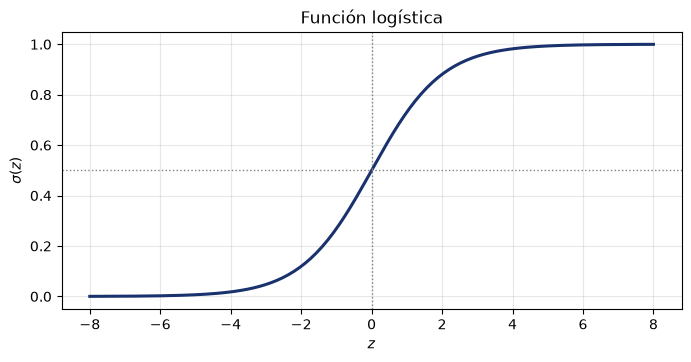

In [6]:
# VERIFICACIÓN — las propiedades de la sigmoide
print("sigma(0)      =", sigmoide(np.array([0.0]))[0])
print("sigma(2)      =", sigmoide(np.array([2.0]))[0].round(4))
print("sigma(-2)     =", sigmoide(np.array([-2.0]))[0].round(4))
print("sigma(-1000)  =", sigmoide(np.array([-1000.0]))[0], " (sin desborde)")

z = np.linspace(-8, 8, 200)
assert np.isclose(sigmoide(np.array([0.0]))[0], 0.5)
assert np.all(np.diff(sigmoide(z)) > 0), "debe ser creciente"
assert np.allclose(sigmoide(-z), 1 - sigmoide(z)), "debe cumplir sigma(-z) = 1 - sigma(z)"
print("\nPropiedades verificadas: vale 0,5 en el origen, es creciente y es simétrica.")

fig, ax = plt.subplots()
ax.plot(z, sigmoide(z), color=AZUL, lw=2.2)
ax.axhline(0.5, color="gray", ls=":", lw=1)
ax.axvline(0, color="gray", ls=":", lw=1)
ax.set_xlabel("$z$")
ax.set_ylabel(r"$\sigma(z)$")
ax.set_title("Función logística")
plt.show()

---

# 2. La entropía cruzada

$$
J(\boldsymbol\beta) = -\frac{1}{n}\sum_{i=1}^n\Bigl[y_i\log \hat p_i + (1-y_i)\log(1-\hat p_i)\Bigr]
$$

### Ejercicio 2

Implementarla. **Cuidado con $\log(0)$:** si alguna probabilidad estimada llega a 0 o a 1
por redondeo, el logaritmo devuelve `-inf` y el costo se vuelve `nan`. Recortar las
probabilidades a $[\varepsilon,\,1-\varepsilon]$ con $\varepsilon = 10^{-12}$ es la
solución habitual.

In [7]:
def entropia_cruzada(y: np.ndarray, p: np.ndarray) -> float:
    """Entropía cruzada promedio entre las etiquetas y las probabilidades estimadas.

    Parámetros
    ----------
    y : (n,) etiquetas en {0, 1}
    p : (n,) probabilidades estimadas de la clase positiva

    Devuelve
    --------
    float : el costo promedio
    """
    epsilon = 1e-12
    p_segura = np.clip(p, epsilon, 1 - epsilon)

    perdida = -(
        y * np.log(p_segura)
        + (1 - y) * np.log(1 - p_segura)
    )

    return float(np.mean(perdida))

In [8]:
# VERIFICACIÓN — contra la implementación de scikit-learn
from sklearn.metrics import log_loss

p_prueba = np.array([0.9, 0.3, 0.1, 0.8])
y_prueba = np.array([1.0, 1.0, 0.0, 0.0])

print("propia      :", round(entropia_cruzada(y_prueba, p_prueba), 6))
print("scikit-learn:", round(log_loss(y_prueba, p_prueba), 6))
print("¿Coinciden?", np.isclose(entropia_cruzada(y_prueba, p_prueba),
                                log_loss(y_prueba, p_prueba)))

# Dos referencias que conviene tener presentes
tasa_base = y.mean()
print(f"\nCosto de asignar 0,5 a todo        : {entropia_cruzada(y, np.full(n, 0.5)):.4f}")
print(f"Costo de asignar la tasa base a todo: "
      f"{entropia_cruzada(y, np.full(n, tasa_base)):.4f}")
print("Cualquier modelo útil tiene que quedar por debajo de la segunda.")

propia      : 0.756033
scikit-learn: 0.756033
¿Coinciden? True

Costo de asignar 0,5 a todo        : 0.6931
Costo de asignar la tasa base a todo: 0.5247
Cualquier modelo útil tiene que quedar por debajo de la segunda.


---

# 3. El gradiente

$$
\nabla J(\boldsymbol\beta) = \frac{1}{n}\,\mathbf{X}^\top\bigl(\boldsymbol\sigma-\mathbf{y}\bigr)
$$

### Ejercicio 3

Implementarlo. Es la misma forma que en el modelo lineal, con la predicción reemplazada por
la probabilidad estimada.

In [9]:
def gradiente(X: np.ndarray, y: np.ndarray, beta: np.ndarray) -> np.ndarray:
    """Gradiente de la entropía cruzada respecto de los coeficientes.

    Devuelve
    --------
    (p+1,) : (1/n) * X^T (sigma(X beta) - y)
    """
    n = len(y)
    probabilidades = sigmoide(X @ beta)

    return (X.T @ (probabilidades - y)) / n

In [10]:
# VERIFICACIÓN — contra diferencias finitas.
# Detecta un signo cambiado, un factor 1/n olvidado o una traspuesta mal puesta.
def costo(X, y, beta):
    return entropia_cruzada(y, sigmoide(X @ beta))


def gradiente_numerico(X, y, beta, h=1e-5):
    g = np.zeros_like(beta)
    for j in range(len(beta)):
        paso = np.zeros_like(beta)
        paso[j] = h
        g[j] = (costo(X, y, beta + paso) - costo(X, y, beta - paso)) / (2 * h)
    return g


rng = np.random.default_rng(0)
beta_prueba = rng.normal(0, 0.3, X.shape[1])

g_analitico = gradiente(X, y, beta_prueba)
g_numerico = gradiente_numerico(X, y, beta_prueba)

print("analítico:", g_analitico)
print("numérico :", g_numerico)
print("\n¿Coinciden?", np.allclose(g_analitico, g_numerico, rtol=1e-5, atol=1e-8))

analítico: [ 0.3539  0.0653  0.0499  0.0833  0.4995  2.3317  0.1435  3.8074 -0.4513]
numérico : [ 0.3539  0.0653  0.0499  0.0833  0.4995  2.3317  0.1435  3.8074 -0.4513]

¿Coinciden? True


---

# 4. El ajuste

```text
1.  β ← 0
2.  para t = 1 … T:
3.      β ← β − η · gradiente(X, y, β)
4.      registrar el costo
```

Es **el mismo bucle** del laboratorio anterior. Lo único que cambió es la función que
calcula el gradiente.

### Ejercicio 4

Implementar el ajuste. Los atributos vienen en escalas muy distintas —la relación
cuota/ingreso ronda $0{,}3$ y la antigüedad, los 5 años—, de modo que **corresponde
estandarizar antes de iterar**; la celda siguiente lo hace.

In [11]:
#@title Estandarización (ejecutar sin modificar) { display-mode: "form" }
mu, sigma_col = X[:, 1:].mean(axis=0), X[:, 1:].std(axis=0)
Xs = np.column_stack([np.ones(n), (X[:, 1:] - mu) / sigma_col])
print("Desvíos originales:", sigma_col.round(3))
print("Tras estandarizar :", Xs[:, 1:].std(axis=0).round(6))

Desvíos originales: [ 0.164  0.406  0.456  1.425  3.518  0.471 10.393  0.712]
Tras estandarizar : [1. 1. 1. 1. 1. 1. 1. 1.]


In [12]:
def ajustar(X, y, eta=0.5, n_iter=4000):
    """Ajusta la regresión logística por descenso por gradiente.

    Devuelve
    --------
    (beta, historial) : coeficientes finales y costo de cada iteración
    """
    beta = np.zeros(X.shape[1])
    historial = []

    for _ in range(n_iter):
        beta = beta - eta * gradiente(X, y, beta)

        probabilidades = sigmoide(X @ beta)
        historial.append(
            entropia_cruzada(y, probabilidades)
        )

    return beta, np.array(historial)

/home/marcos/ml_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


costo propio       : 0.391229
costo scikit-learn : 0.391229

mayor diferencia entre coeficientes: 0.000000
¿np.allclose(rtol=1e-3)? True


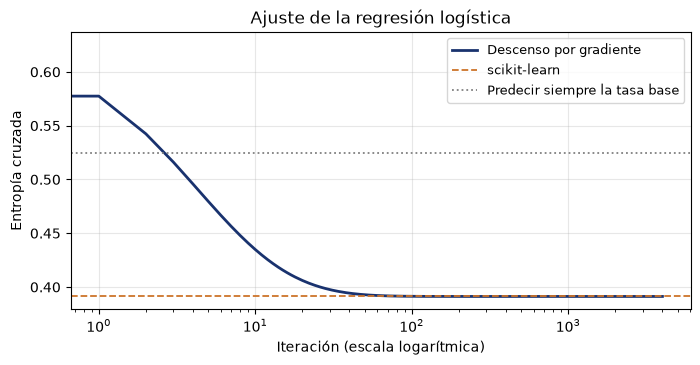

In [13]:
# VERIFICACIÓN — contra scikit-learn.
# penalty=None es obligatorio: por omisión LogisticRegression regulariza, y entonces
# sus coeficientes NO son los de máxima verosimilitud.
from sklearn.linear_model import LogisticRegression

beta_gd, hist = ajustar(Xs, y, eta=0.5, n_iter=4000)

sk = LogisticRegression(penalty=None, max_iter=5000, tol=1e-10).fit(Xs[:, 1:], y)
beta_sk = np.concatenate([sk.intercept_, sk.coef_[0]])

print(f"costo propio       : {hist[-1]:.6f}")
print(f"costo scikit-learn : {costo(Xs, y, beta_sk):.6f}")
print(f"\nmayor diferencia entre coeficientes: {np.max(np.abs(beta_gd - beta_sk)):.6f}")
print("¿np.allclose(rtol=1e-3)?", np.allclose(beta_gd, beta_sk, rtol=1e-3))

fig, ax = plt.subplots()
ax.plot(hist, color=AZUL, lw=2, label="Descenso por gradiente")
ax.axhline(costo(Xs, y, beta_sk), color=NARANJA, ls="--", lw=1.3, label="scikit-learn")
ax.axhline(entropia_cruzada(y, np.full(n, tasa_base)), color="gray", ls=":", lw=1.3,
           label="Predecir siempre la tasa base")
ax.set_xscale("log")
ax.set_xlabel("Iteración (escala logarítmica)")
ax.set_ylabel("Entropía cruzada")
ax.set_title("Ajuste de la regresión logística")
ax.legend(fontsize=9)
plt.show()

### Para analizar

1. ¿Cuántas iteraciones hicieron falta para que el costo dejara de bajar de forma
   apreciable? Compararlo con las **decenas** de iteraciones que necesita L-BFGS, que es lo
   que usa `scikit-learn`.
2. ¿Qué habría pasado si se hubiera ejecutado `LogisticRegression()` sin `penalty=None`?
   Probarlo y comparar la magnitud de los coeficientes.

**Respuesta:**

1. El descenso de gradiente necesitó muchas más iteraciones que L-BFGS para estabilizar el costo. El descenso de gradiente realiza actualizaciones simples utilizando solamente la pendiente, mientras que L-BFGS utiliza información adicional para encontrar más rápidamente la dirección adecuada.

    A pesar de esta diferencia, el costo final y los coeficientes obtenidos por ambos procedimientos prácticamente coinciden.

2. Si se utilizara `LogisticRegression()` sin `penalty=None`, scikit-learn aplicaría regularización por defecto. La regularización penaliza los coeficientes grandes y los acerca a cero.

    Por eso los coeficientes del modelo regularizado tienen, en general, menor magnitud y no coinciden exactamente con los coeficientes de máxima verosimilitud obtenidos mediante nuestro descenso de gradiente.

---

# 5. Interpretación de los coeficientes

Acá está el objeto de todo lo anterior. Como los coeficientes estandarizados no están en las
unidades del problema, el primer paso es **devolverlos a la escala original**: si
$\tilde x_j = (x_j-\bar x_j)/s_j$, entonces el coeficiente en unidades originales es
$\beta_j / s_j$, y el intercepto se corrige restando $\sum_j \beta_j\bar x_j/s_j$.

### Ejercicio 5

1. Recuperar los coeficientes en las unidades originales.
2. Armar un `DataFrame` con el atributo, el coeficiente y su razón de odds $e^{\beta_j}$.
3. Comparar contra los coeficientes verdaderos, que se dan en la celda siguiente.

**La relación cuota/ingreso recorre $(0{,}03;\ 0{,}85)$**: un aumento de una unidad está
fuera de lo observado, de modo que su razón de odds corresponde informarla **por cada
$0{,}10$**, es decir $e^{0{,}10\,\beta_j}$.

In [14]:
#@title Coeficientes verdaderos del modelo generador { display-mode: "form" }
# El conjunto es sintético: la respuesta se generó con este modelo logístico.
# Poder contrastar contra la verdad es el motivo por el que se usa un dataset simulado.
VERDADEROS = {
    "intercepto": -3.10, "cuota_ingreso": 6.00, "hist_atrasos": 1.10,
    "hist_sin": 0.45, "consultas_buro_12m": 0.25,
    "antiguedad_laboral_anios": -0.08, "tiene_garantia": -0.85,
    "edad_c": -0.015, "log_monto": 0.30,
}
INCREMENTO = {k: 1.0 for k in VERDADEROS}
INCREMENTO["cuota_ingreso"] = 0.10
print("Coeficientes verdaderos:", VERDADEROS)

Coeficientes verdaderos: {'intercepto': -3.1, 'cuota_ingreso': 6.0, 'hist_atrasos': 1.1, 'hist_sin': 0.45, 'consultas_buro_12m': 0.25, 'antiguedad_laboral_anios': -0.08, 'tiene_garantia': -0.85, 'edad_c': -0.015, 'log_monto': 0.3}


In [15]:
# Volver a las unidades originales
beta_orig = np.empty_like(beta_gd)

beta_orig[1:] = beta_gd[1:] / sigma_col

beta_orig[0] = (
    beta_gd[0]
    - np.sum(beta_gd[1:] * mu / sigma_col)
)

incrementos = np.array([
    INCREMENTO[nombre]
    for nombre in NOMBRES
])

beta_verdaderos = np.array([
    VERDADEROS[nombre]
    for nombre in NOMBRES
])

tabla_coeficientes = pd.DataFrame({
    "atributo": NOMBRES,
    "beta_estimado": beta_orig,
    "beta_verdadero": beta_verdaderos,
    "incremento": incrementos,
    "razon_odds": np.exp(beta_orig * incrementos)
})

display(tabla_coeficientes.round(4))

# Verificar que ambas versiones producen lo mismo
p_estandarizadas = sigmoide(Xs @ beta_gd)
p_originales = sigmoide(X @ beta_orig)

print(
    "¿Producen las mismas probabilidades?",
    np.allclose(p_estandarizadas, p_originales)
)

print(
    "Mayor diferencia:",
    np.max(np.abs(p_estandarizadas - p_originales))
)

,atributo,beta_estimado,beta_verdadero,incremento,razon_odds
0,intercepto,-3.3116,-3.100,1.0,0.0365
1,cuota_ingreso,6.2350,6.000,0.1,1.8654
2,hist_atrasos,0.9619,1.100,1.0,2.6166
3,hist_sin,0.5369,0.450,1.0,1.7106
4,consultas_buro_12m,0.2378,0.250,1.0,1.2685
5,antiguedad_laboral_anios,-0.0838,-0.080,1.0,0.9196
6,tiene_garantia,-0.9001,-0.850,1.0,0.4065
7,edad_c,-0.0143,-0.015,1.0,0.9858
8,log_monto,0.1601,0.300,1.0,1.1736


¿Producen las mismas probabilidades? True
Mayor diferencia: 3.3306690738754696e-16


### Para analizar

1. ¿Qué atributo tiene la razón de odds más alta? Expresarlo en una frase **sobre el
   problema**, no sobre el modelo.
2. El coeficiente del logaritmo del monto quedó bastante por debajo de su valor verdadero.
   **¿Por qué?** Pensar qué otra columna del modelo ya contiene esa información.
3. La razón de odds de la garantía ronda $0{,}41$. ¿Es correcto decir que «tener garantía
   reduce la probabilidad de incumplir un 59 %»?

**Respuesta:**

1. Para identificar el atributo con la mayor razón de odds no debe considerarse el intercepto. Según la tabla, el historial crediticio con atrasos presenta una de las razones de odds más altas.

    Manteniendo constantes los demás atributos, una persona con historial de atrasos tiene odds de incumplimiento mayores que una persona cuyo historial está al día, que es la categoría de referencia.

    La relación cuota/ingreso también tiene un efecto importante: un aumento de 0.10 en la proporción de la cuota respecto del ingreso multiplica las odds de incumplimiento por la razón de odds mostrada en la tabla.

2. El coeficiente del logaritmo del monto puede quedar por debajo de su valor verdadero porque la variable `cuota_ingreso` ya contiene parte de la información relacionada con el monto solicitado.

    Al incluir ambas variables, cada coeficiente representa el efecto de su atributo manteniendo constante el otro. Como comparten información, resulta más difícil estimar por separado el efecto del monto.

3. No es correcto afirmar que una razón de odds de 0.41 reduce la probabilidad de incumplimiento en un 59 %.

    Lo que disminuye un 59 % son las odds de incumplimiento, porque `1 - 0.41 = 0.59`. El cambio en la probabilidad depende de cuál era la probabilidad inicial. Odds y probabilidades no son lo mismo.

### Ejercicio 6

Un solicitante concreto: 30 años, dos años de antigüedad laboral, historial **con atrasos**,
tres consultas al buró, **sin** garantía, pide 6000 dólares con una cuota que representa el
35 % de su ingreso.

1. Calcular su estimación lineal, sus odds y su probabilidad estimada.
2. Recalcular la probabilidad **si ofreciera una garantía**.
3. ¿Cambia de lado del umbral 0,5?

In [16]:
solicitud = {
    "cuota_ingreso": 0.35,
    "hist_atrasos": 1,
    "hist_sin": 0,
    "consultas_buro_12m": 3,
    "antiguedad_laboral_anios": 2.0,
    "tiene_garantia": 0,
    "edad_c": 30 - 38,
    "log_monto": np.log(6000) - np.log(10_000),
}

# Vector en el mismo orden usado por el modelo
x_solicitud = np.array(
    [1.0] + [
        solicitud[atributo]
        for atributo in ATRIBUTOS
    ]
)

z_sin_garantia = x_solicitud @ beta_orig
odds_sin_garantia = np.exp(z_sin_garantia)
p_sin_garantia = sigmoide(
    np.array([z_sin_garantia])
)[0]

# Copiar y cambiar tiene_garantia a 1
solicitud_garantia = solicitud.copy()
solicitud_garantia["tiene_garantia"] = 1

x_con_garantia = np.array(
    [1.0] + [
        solicitud_garantia[atributo]
        for atributo in ATRIBUTOS
    ]
)

z_con_garantia = x_con_garantia @ beta_orig
odds_con_garantia = np.exp(z_con_garantia)
p_con_garantia = sigmoide(
    np.array([z_con_garantia])
)[0]

resultado_solicitud = pd.DataFrame({
    "situacion": ["Sin garantía", "Con garantía"],
    "estimacion_lineal": [
        z_sin_garantia,
        z_con_garantia
    ],
    "odds": [
        odds_sin_garantia,
        odds_con_garantia
    ],
    "probabilidad": [
        p_sin_garantia,
        p_con_garantia
    ],
    "supera_0.5": [
        p_sin_garantia >= 0.5,
        p_con_garantia >= 0.5
    ]
})

display(resultado_solicitud.round(4))

print(
    "¿Cambia de lado del umbral?",
    (p_sin_garantia >= 0.5)
    != (p_con_garantia >= 0.5)
)

,situacion,estimacion_lineal,odds,probabilidad,supera_0.5
0,Sin garantía,0.4112,1.5086,0.6014,True
1,Con garantía,-0.4889,0.6133,0.3802,False


¿Cambia de lado del umbral? True


---

# 6. De la probabilidad a la decisión

El modelo devuelve una probabilidad. Para decidir hay que compararla contra un **umbral**, y
esa elección no proviene del modelo.

### Ejercicio 7

1. Calcular las probabilidades estimadas para las 4000 solicitudes.
2. Para umbrales de $0{,}1$ a $0{,}9$ en pasos de $0{,}1$, armar un `DataFrame` con:
   la proporción de incumplimientos detectados, la proporción de cumplidores marcados, y la
   exactitud.
3. Comparar la exactitud con la de predecir **«cumple» para todos**.
4. Graficar el histograma de las probabilidades estimadas, separado por clase real.

,umbral,incumplimientos_detectados,cumplidores_marcados,exactitud,falsos_negativos,falsos_positivos,costo_relativo_8a1
0,0.1,0.891,0.513,0.575,95,1605,2365
1,0.2,0.738,0.250,0.747,229,783,2615
2,0.3,0.607,0.139,0.806,343,435,3179
3,0.4,0.493,0.083,0.824,443,260,3804
4,0.5,0.400,0.043,0.835,524,136,4328
5,0.6,0.315,0.025,0.831,598,79,4863
6,0.7,0.238,0.011,0.825,665,34,5354
7,0.8,0.158,0.005,0.812,735,15,5895
8,0.9,0.072,0.000,0.797,810,1,6481


Exactitud de predecir 'cumple' para todos: 0.782

Umbral con mayor exactitud:


,umbral,incumplimientos_detectados,cumplidores_marcados,exactitud,falsos_negativos,falsos_positivos,costo_relativo_8a1
4,0.5,0.4,0.043,0.835,524.0,136.0,4328.0


Umbral con menor costo relativo:


,umbral,incumplimientos_detectados,cumplidores_marcados,exactitud,falsos_negativos,falsos_positivos,costo_relativo_8a1
0,0.1,0.891,0.513,0.575,95.0,1605.0,2365.0


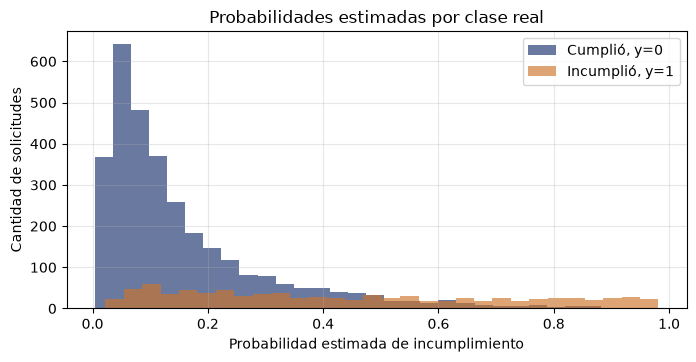

In [17]:
# Probabilidades de las 4000 solicitudes
p_hat = sigmoide(X @ beta_orig)

filas = []

for umbral in np.arange(0.1, 1.0, 0.1):
    pred = (p_hat >= umbral).astype(int)

    positivos_reales = y == 1
    negativos_reales = y == 0

    incumplimientos_detectados = np.mean(
        pred[positivos_reales] == 1
    )

    cumplidores_marcados = np.mean(
        pred[negativos_reales] == 1
    )

    exactitud = np.mean(pred == y)

    falsos_negativos = np.sum(
        (y == 1) & (pred == 0)
    )

    falsos_positivos = np.sum(
        (y == 0) & (pred == 1)
    )

    # Incobrable cuesta ocho veces un rechazo incorrecto
    costo_relativo = (
        8 * falsos_negativos
        + falsos_positivos
    )

    filas.append({
        "umbral": umbral,
        "incumplimientos_detectados": incumplimientos_detectados,
        "cumplidores_marcados": cumplidores_marcados,
        "exactitud": exactitud,
        "falsos_negativos": falsos_negativos,
        "falsos_positivos": falsos_positivos,
        "costo_relativo_8a1": costo_relativo
    })

tabla_umbrales = pd.DataFrame(filas)

display(tabla_umbrales.round(3))

exactitud_mayoritaria = max(
    y.mean(),
    1 - y.mean()
)

print(
    "Exactitud de predecir 'cumple' para todos:",
    round(exactitud_mayoritaria, 3)
)

mejor_exactitud = tabla_umbrales.loc[
    tabla_umbrales["exactitud"].idxmax()
]

menor_costo = tabla_umbrales.loc[
    tabla_umbrales["costo_relativo_8a1"].idxmin()
]

print("\nUmbral con mayor exactitud:")
display(mejor_exactitud.to_frame().T.round(3))

print("Umbral con menor costo relativo:")
display(menor_costo.to_frame().T.round(3))

# Histograma separado por clase real
fig, ax = plt.subplots()

ax.hist(
    p_hat[y == 0],
    bins=30,
    alpha=0.65,
    color=AZUL,
    label="Cumplió, y=0"
)

ax.hist(
    p_hat[y == 1],
    bins=30,
    alpha=0.65,
    color=NARANJA,
    label="Incumplió, y=1"
)

ax.set_xlabel("Probabilidad estimada de incumplimiento")
ax.set_ylabel("Cantidad de solicitudes")
ax.set_title("Probabilidades estimadas por clase real")
ax.legend()

plt.show()

### DECIDE

La institución estima que un crédito incobrable cuesta unas **ocho veces** lo que cuesta
rechazar a un cliente que habría cumplido.

1. Con esa relación de costos, ¿qué umbral de la tabla elegirías? Justificarlo con las dos
   columnas de la tabla, no con la exactitud.
2. La exactitud es máxima en un umbral bastante alto. **¿Por qué esa métrica lleva a la
   decisión equivocada** en este problema?
3. ¿Qué información, que no está en los datos, hizo falta para responder la primera
   pregunta?

**Respuesta:**

1. Elegiría el umbral que presenta el menor valor en `costo_relativo_8a1`. Con una relación de costos de 8 a 1, es más importante detectar una proporción alta de incumplimientos, aunque eso implique marcar incorrectamente a más cumplidores.

    En la tabla, el umbral elegido es ___. Con ese umbral se detecta una proporción de ___ de los incumplimientos y se marca incorrectamente una proporción de ___ de los cumplidores.

2. La exactitud conduce a una decisión equivocada porque considera que todos los errores cuestan lo mismo. Sin embargo, en este problema no detectar un incumplimiento cuesta ocho veces más que rechazar a alguien que habría cumplido.

    Un umbral alto puede obtener buena exactitud porque clasifica a la mayoría como cumplidores, pero deja pasar demasiados incumplimientos costosos.

3. Para elegir el umbral fue necesario conocer el costo económico de cada tipo de error: cuánto cuesta aprobar un crédito que no será pagado y cuánto cuesta rechazar a un cliente que habría cumplido.

    Esa información no se encuentra en los atributos ni en las respuestas históricas. Debe ser proporcionada por la institución y forma parte de la decisión de negocio.

---

## Cierre

- **El modelo se ajusta iterando**, porque el sistema $\mathbf{X}^\top(\boldsymbol\sigma-\mathbf{y})=\mathbf{0}$
  no se despeja. El bucle es el mismo del laboratorio anterior con una línea distinta.
- **Los coeficientes se leen en odds.** $e^{\beta_j}$ multiplica odds, no
  probabilidades, y esa distinción cambia la interpretación.
- **Un coeficiente responde qué aporta un atributo dado el resto del modelo**, no cuánto
  importa: el monto quedó subestimado porque la cuota/ingreso ya lo contenía.
- **El modelo produce probabilidades; la decisión exige un umbral**, y ese umbral traduce
  los costos del problema, que no están en los datos.

## Para seguir explorando

Sin obligación y fuera del tiempo de clase:

1. **Separación perfecta.** Agregar al modelo una columna que sea casi una copia de la
   respuesta —por ejemplo `y` con un 2 % de las etiquetas cambiadas— y volver a ajustar.
   Observar la magnitud de los coeficientes. ¿Qué pasa si se aumenta el número de
   iteraciones?
2. **La regularización como remedio.** Repetir lo anterior con `LogisticRegression()` en su
   configuración por omisión y comparar las magnitudes.
3. **Newton en lugar de gradiente.** Implementar un paso de Newton usando la Hessiana
   $\frac1n\mathbf{X}^\top\mathbf{D}\mathbf{X}$ con $\mathbf{D}=\operatorname{diag}\{\hat p_i(1-\hat p_i)\}$
   y contar cuántas iteraciones necesita para alcanzar el mismo costo.

In [18]:
rng = np.random.default_rng(42)

# Copia casi perfecta de la respuesta
casi_y = y.copy()

# Cambiar el 2 % de las etiquetas
cantidad_cambios = int(0.02 * len(y))

indices_cambiados = rng.choice(
    len(y),
    size=cantidad_cambios,
    replace=False
)

casi_y[indices_cambiados] = (
    1 - casi_y[indices_cambiados]
)

# Agregarla a la matriz ya estandarizada
Xs_separacion = np.column_stack([
    Xs,
    casi_y
])

beta_separacion, hist_separacion = ajustar(
    Xs_separacion,
    y,
    eta=0.5,
    n_iter=4000
)

nombres_separacion = NOMBRES + ["casi_copia_y"]

coef_separacion = pd.DataFrame({
    "atributo": nombres_separacion,
    "coeficiente": beta_separacion,
    "valor_absoluto": np.abs(beta_separacion)
})

display(
    coef_separacion.sort_values(
        "valor_absoluto",
        ascending=False
    ).round(3)
)

print("Costo final:", hist_separacion[-1])

,atributo,coeficiente,valor_absoluto
9,casi_copia_y,7.711,7.711
0,intercepto,-5.404,5.404
1,cuota_ingreso,0.888,0.888
2,hist_atrasos,0.544,0.544
6,tiene_garantia,-0.483,0.483
4,consultas_buro_12m,0.439,0.439
3,hist_sin,0.328,0.328
8,log_monto,0.286,0.286
7,edad_c,-0.259,0.259
5,antiguedad_laboral_anios,-0.122,0.122


Costo final: 0.06927791352719657


In [19]:
beta_separacion_20000, hist_20000 = ajustar(
    Xs_separacion,
    y,
    eta=0.5,
    n_iter=20000
)

comparacion_iteraciones = pd.DataFrame({
    "atributo": nombres_separacion,
    "beta_4000": beta_separacion,
    "beta_20000": beta_separacion_20000
})

display(comparacion_iteraciones.round(3))

print(
    "Coeficiente de casi_copia_y con 4000 iteraciones:",
    beta_separacion[-1]
)

print(
    "Coeficiente de casi_copia_y con 20000 iteraciones:",
    beta_separacion_20000[-1]
)

,atributo,beta_4000,beta_20000
0,intercepto,-5.404,-5.468
1,cuota_ingreso,0.888,0.899
2,hist_atrasos,0.544,0.554
3,hist_sin,0.328,0.334
4,consultas_buro_12m,0.439,0.446
5,antiguedad_laboral_anios,-0.122,-0.122
6,tiene_garantia,-0.483,-0.490
7,edad_c,-0.259,-0.263
8,log_monto,0.286,0.291
9,casi_copia_y,7.711,7.791


Coeficiente de casi_copia_y con 4000 iteraciones: 7.711469483338806
Coeficiente de casi_copia_y con 20000 iteraciones: 7.791093723977255


**Respuesta**

La columna `casi_copia_y` obtiene un coeficiente de magnitud muy grande porque permite separar casi perfectamente las clases.

Al aumentar el número de iteraciones, su coeficiente continúa creciendo. El modelo intenta asignar probabilidades cada vez más cercanas a 0 y 1. Con separación perfecta, la estimación de máxima verosimilitud no tiene un valor finito y los coeficientes pueden crecer indefinidamente.

In [20]:
modelo_regularizado = LogisticRegression(
    max_iter=5000
)

modelo_regularizado.fit(
    Xs_separacion[:, 1:],
    y
)

beta_regularizado = np.concatenate([
    modelo_regularizado.intercept_,
    modelo_regularizado.coef_[0]
])

comparacion_regularizacion = pd.DataFrame({
    "atributo": nombres_separacion,
    "sin_regularizacion": beta_separacion_20000,
    "con_regularizacion": beta_regularizado,
    "abs_sin_regularizacion": np.abs(beta_separacion_20000),
    "abs_con_regularizacion": np.abs(beta_regularizado)
})

display(
    comparacion_regularizacion.sort_values(
        "abs_sin_regularizacion",
        ascending=False
    ).round(3)
)

,atributo,sin_regularizacion,con_regularizacion,abs_sin_regularizacion,abs_con_regularizacion
9,casi_copia_y,7.791,7.160,7.791,7.160
0,intercepto,-5.468,-5.014,5.468,5.014
1,cuota_ingreso,0.899,0.803,0.899,0.803
2,hist_atrasos,0.554,0.481,0.554,0.481
6,tiene_garantia,-0.490,-0.436,0.490,0.436
4,consultas_buro_12m,0.446,0.394,0.446,0.394
3,hist_sin,0.334,0.292,0.334,0.292
8,log_monto,0.291,0.267,0.291,0.267
7,edad_c,-0.263,-0.232,0.263,0.232
5,antiguedad_laboral_anios,-0.122,-0.130,0.122,0.130


**Respuesta**

Con regularización, los coeficientes tienen menor magnitud. La penalización evita que el coeficiente de `casi_copia_y` crezca excesivamente.

La regularización produce estimaciones más estables cuando existe separación perfecta o casi perfecta, aunque introduce cierto sesgo al acercar los coeficientes a cero.

In [21]:
def ajustar_newton(X, y, n_iter=100, tolerancia=1e-10):
    beta = np.zeros(X.shape[1])
    historial = []

    for iteracion in range(n_iter):
        p = sigmoide(X @ beta)

        # Gradiente
        g = X.T @ (p - y) / len(y)

        # Diagonal de D
        pesos = p * (1 - p)

        # X.T @ D @ X, sin construir D
        H = X.T @ (X * pesos[:, None]) / len(y)

        # Paso de Newton: beta nueva = beta - H^-1 g
        paso = np.linalg.solve(H, g)
        beta = beta - paso

        costo_actual = costo(X, y, beta)
        historial.append(costo_actual)

        if np.linalg.norm(paso) < tolerancia:
            return beta, np.array(historial), iteracion + 1

    return beta, np.array(historial), n_iter

Iteraciones de Newton: 7
Costo final Newton: 0.39122947346503656
Costo final gradiente: 0.39122947346503656
¿Coeficientes similares? True


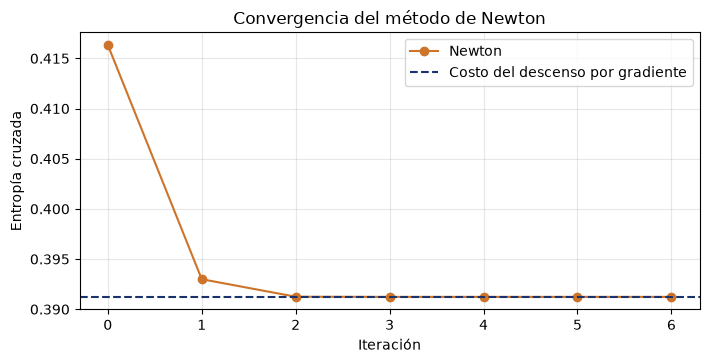

In [22]:
beta_newton, hist_newton, iteraciones_newton = ajustar_newton(
    Xs,
    y
)

print("Iteraciones de Newton:", iteraciones_newton)
print("Costo final Newton:", hist_newton[-1])
print("Costo final gradiente:", hist[-1])

print(
    "¿Coeficientes similares?",
    np.allclose(
        beta_newton,
        beta_gd,
        rtol=1e-3,
        atol=1e-4
    )
)

fig, ax = plt.subplots()

ax.plot(
    hist_newton,
    marker="o",
    color=NARANJA,
    label="Newton"
)

ax.axhline(
    hist[-1],
    color=AZUL,
    linestyle="--",
    label="Costo del descenso por gradiente"
)

ax.set_xlabel("Iteración")
ax.set_ylabel("Entropía cruzada")
ax.set_title("Convergencia del método de Newton")
ax.legend()

plt.show()

**Respuesta** 

El método de Newton alcanza aproximadamente el mismo costo que el descenso por gradiente, pero necesita muchas menos iteraciones.

Esto ocurre porque Newton utiliza tanto el gradiente como la curvatura representada por la Hessiana. Cada iteración es más costosa, ya que requiere resolver un sistema de ecuaciones, pero suele avanzar mucho más rápidamente hacia el mínimo.